# Experiment 2: Effect of Matrix Size and Sparsity

Compare the final objective values of PALM, iPALM, and FISTA-PALM across different matrix sizes and sparsity levels.

**Setup**
- Matrix sizes: $100 \times 80$, $500 \times 200$, and $1000 \times 600$
- Ranks: $r = 10$, $r = 50$, and $r = 200$
- Sparsity levels in $Y$: $10\%$, $25\%$, and $33\%$
- Initialisation: random nonnegative
- Iterations: $100$

**Goal**

Evaluate how the methods behave as the problem size and sparsity level change.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))

from src.solvers.palm import PALM
from src.solvers.ipalm import IPALM
from src.solvers.fista_palm import FISTAPALM

from src.utils.problem_factory import make_matrix_factorisation_problem
from src.utils.plotting import plot_bar
from src.utils.io import make_fig_path, save_table

In [2]:
np.random.seed(42)

matrix_configs = [
    (100, 80, 10),
    (500, 200, 50),
    (1000, 600, 200),
]

sparsity_levels = [0.10, 0.25, 0.33]
max_iter = 100
gamma = 1.2

solvers = {
    "PALM": PALM(max_iter=max_iter),
    "iPALM": IPALM(max_iter=max_iter),
    "FISTA-PALM": FISTAPALM(max_iter=max_iter),
}

In [3]:
records = []
results = {}

for m, n, r in matrix_configs:
    config_label = f"{m}x{n}, r={r}"
    results[config_label] = {}

    for sparsity in sparsity_levels:
        sparsity_label = f"{int(sparsity * 100)}%"
        results[config_label][sparsity_label] = {}

        A = np.random.rand(m, r) @ np.random.rand(n, r).T
        X0 = np.abs(np.random.randn(m, r))
        Y0 = np.abs(np.random.randn(n, r))

        problem = make_matrix_factorisation_problem(A, r, sparsity, gamma=gamma)

        for method_name, solver in solvers.items():
            _, _, hist = solver.solve(problem, X0.copy(), Y0.copy())

            final_obj = hist[-1]
            iterations = len(hist) - 1

            results[config_label][sparsity_label][method_name] = final_obj

            records.append({
                "Matrix": config_label,
                "m": m,
                "n": n,
                "rank": r,
                "Sparsity": sparsity_label,
                "Method": method_name,
                "Final Objective": final_obj,
                "Iterations": iterations,
            })

## Summary table

Final objective values after $100$ iterations.

In [4]:
df = pd.DataFrame(records)

params = {
    "configs": len(matrix_configs),
    "slevels": len(sparsity_levels),
    "iter": max_iter,
}

save_table(
    df,
    ROOT,
    "sparsity_size_summary",
    params,
)

df

,Matrix,m,n,rank,Sparsity,Method,Final Objective,Iterations
0,"100x80, r=10",100,80,10,10%,PALM,6.499546e+03,100
1,"100x80, r=10",100,80,10,10%,iPALM,2.635404e+02,18
2,"100x80, r=10",100,80,10,10%,FISTA-PALM,6.014879e+03,100
3,"100x80, r=10",100,80,10,25%,PALM,3.259058e+02,100
4,"100x80, r=10",100,80,10,25%,iPALM,2.267906e+02,100
5,"100x80, r=10",100,80,10,25%,FISTA-PALM,1.863187e+02,100
6,"100x80, r=10",100,80,10,33%,PALM,2.068732e+02,100
7,"100x80, r=10",100,80,10,33%,iPALM,8.974383e+02,100
8,"100x80, r=10",100,80,10,33%,FISTA-PALM,1.417630e+02,100
9,"500x200, r=50",500,200,50,10%,PALM,1.253341e+04,100


## Final objective comparison

Grouped bar plots comparing the final objective across sparsity levels for each matrix size.

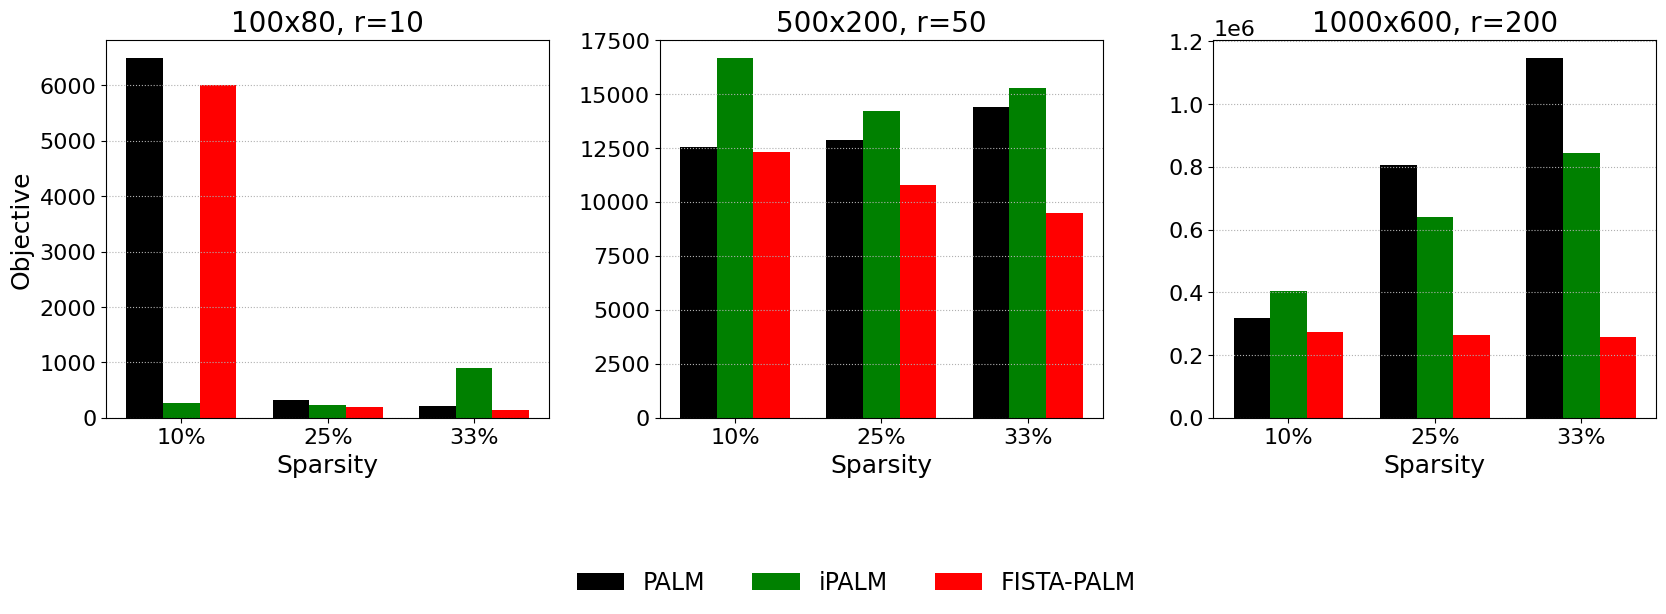

In [6]:
plot_bar(
    results,
    matrix_configs,
    sparsity_levels,
    save_path=make_fig_path(ROOT, "sparsity_size_objectives", params),
)

## Observations

- FISTA-PALM achieves the lowest final objective in most configurations.
- The performance gap becomes more pronounced for the largest matrix size.
- PALM becomes noticeably worse as sparsity is relaxed in the largest configuration.
- iPALM is not consistently better than PALM here; its performance depends strongly on the matrix size and sparsity level.